In [1]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path

In [2]:
def plot_all(set_alpha):
    with open(f"power_s/downloads/auto_CL_a{set_alpha}_c5.pkl", "rb") as f:
        dict_all= pickle.load(f)
    train_losses, val_losses, confusion_matrices, val_accuracies, lyas, time, lya_train, records = [dict_all[k] for k in dict_all]
    fig, axes = plt.subplots(3,2, figsize=(8,10))

    plt.subplots_adjust(
        wspace=0.5,
        hspace=0.5
    )

    axes[0,0].plot(train_losses)
    axes[0,0].set_title("Train Losses")

    axes[0,1].plot(val_losses)
    axes[0,1].set_title("Validation Losses")

    sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
    axes[1,0].set_title("Confusion Matrix")

    axes[1,1].plot(val_accuracies)
    axes[1,1].set_title("Validation Accuracies")

    # axes[2,0].plot(lya_train)
    # axes[2,0].set_title("Lyapunov")

    # axes[2,0].plot(lyas)
    # axes[2,0].set_title("Lyapunov")

    axes[2,0].plot(records)
    axes[2,0].set_title("Lyapunov")

    axes[2,1].axis("off")

    for ax in axes.flatten():
        ax.grid(True, linestyle="--", alpha=0.4)
    

    # plt.savefig(f"{set_alpha}_1000.png", dpi=300)

In [51]:
def get_val_acc(set_alpha):
    with open(f"power_s/downloads/auto_CL_a{set_alpha}_c5.pkl", "rb") as f:
        dict_all= pickle.load(f)
    train_losses, val_losses, confusion_matrices, val_accuracies, lyas, time, lya_train, records = [dict_all[k] for k in dict_all]
    return val_accuracies

In [52]:
alpha_list = [0.1, 0.4, 0.6, 0.8, 1.0]

all_vals = []
for i in alpha_list:
    all_vals.append(get_val_acc(i))

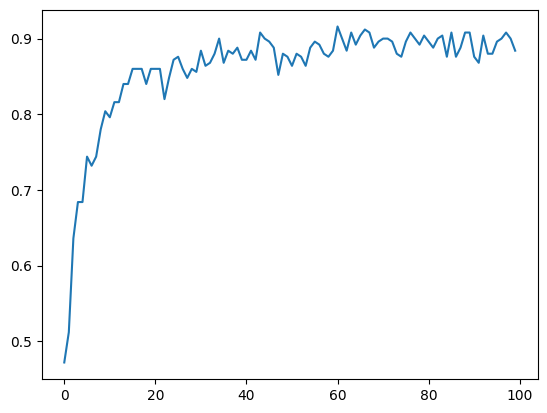

In [61]:
plt.plot(all_vals[-1])

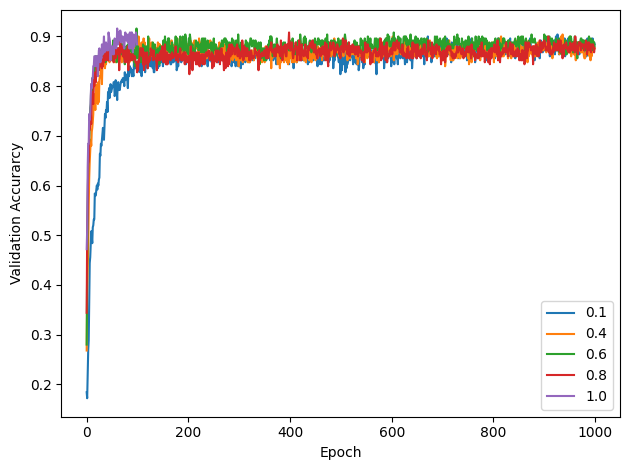

In [99]:
for i in range(len(all_vals)):
    plt.plot(all_vals[i], label=alpha_list[i])
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation Accurarcy")
plt.tight_layout()
plt.savefig("val_acc.png", dpi=300)

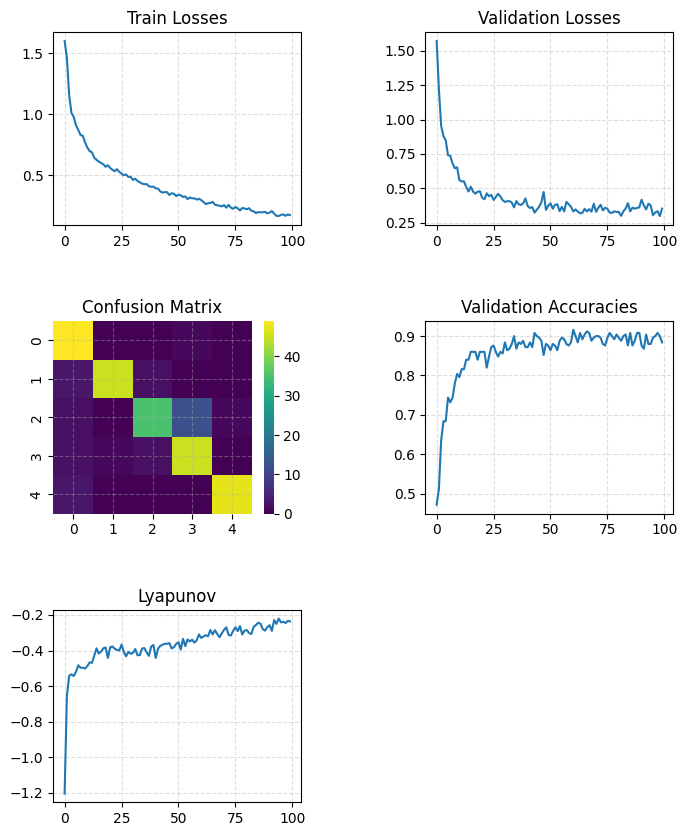

In [8]:
plot_all(1.0)

In [90]:
num_last = 20

In [91]:
def acc(set_alpha):
    with open(f"power_s/downloads/auto_CL_a{set_alpha}_c5.pkl", "rb") as f:
        dict_all= pickle.load(f)
    train_losses, val_losses, confusion_matrices, val_accuracies, lyas, time, lya_train, records = [dict_all[k] for k in dict_all]
    ave_lya = sum(records[-num_last:])/len(records[-num_last:])
    ave_acc = sum(val_accuracies[-num_last:])/len(val_accuracies[-num_last:])
    return ave_lya, ave_acc

In [92]:
alpha_list = [0.1, 0.4, 0.6, 0.8, 1.0]
lya_list = []
acc_list = []
for i in alpha_list:
    ave_lya, ave_acc = acc(i)
    lya_list.append(ave_lya)
    acc_list.append(ave_acc)

Text(0, 0.5, 'Validation accuracy (avg last 5)')

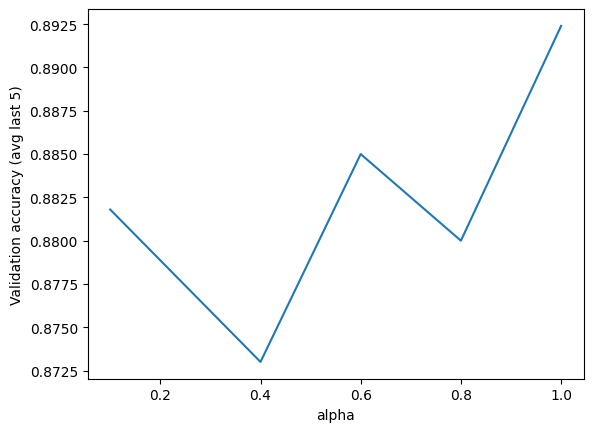

In [93]:
plt.plot(alpha_list, acc_list)
plt.xlabel("alpha")
plt.ylabel("Validation accuracy (avg last 5)")
# plt.savefig("acc.png", dpi=300)

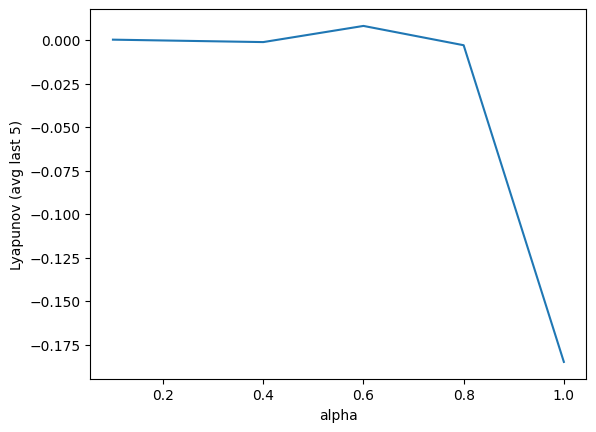

In [94]:
plt.plot(alpha_list, lya_list)
plt.xlabel("alpha")
plt.ylabel("Lyapunov (avg last 5)")
plt.savefig("lya.png", dpi=300)

In [35]:
lya_list

[-0.021239279210567473,
 0.03308642879128456,
 -0.008504585176706315,
 0.005160872358828783,
 -0.017056281497934832,
 0.0110043466091156,
 -0.03329999889247119,
 -0.1260068029165268,
 -0.1864067554473877]

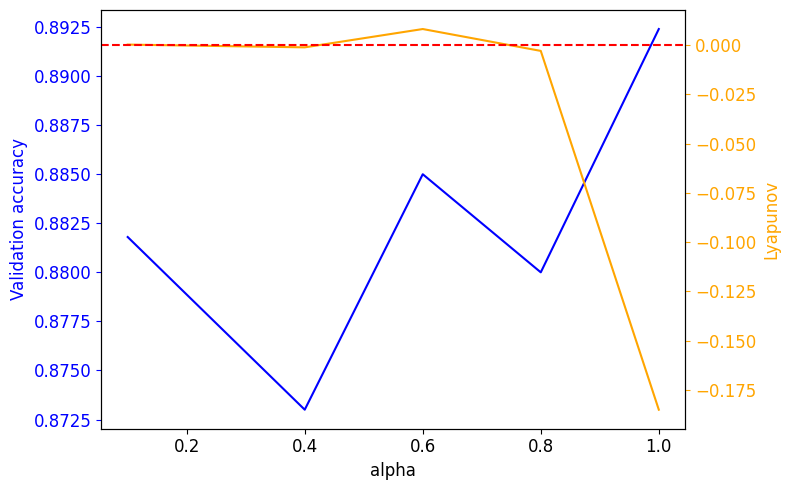

In [95]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.set_xlabel('alpha', fontsize=12)
ax1.tick_params(labelsize=12)


ax1.plot(alpha_list, acc_list, color='blue')
ax1.set_ylabel('Validation accuracy', color='blue', fontsize=12)
ax1.tick_params(axis='y', colors='blue', labelsize=12)

ax2 = ax1.twinx()
ax2.plot(alpha_list, lya_list, color='orange')
ax2.set_ylabel('Lyapunov', color='orange', fontsize=12)
ax2.tick_params(axis='y', colors='orange', labelsize=12)

ax2.axhline(y=0, color='red', linestyle='--')


plt.tight_layout()
plt.savefig("lya_acc.png", dpi=300)

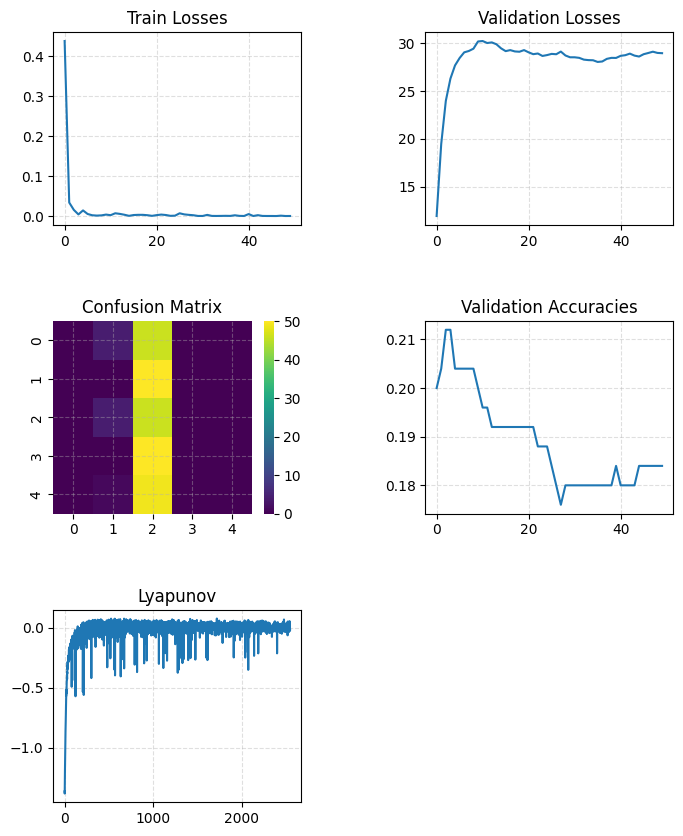

In [93]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

# axes[2,0].plot(lya_train)
# axes[2,0].set_title("Lyapunov")

axes[2,0].plot(records)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("0.01_50.png", dpi=300)

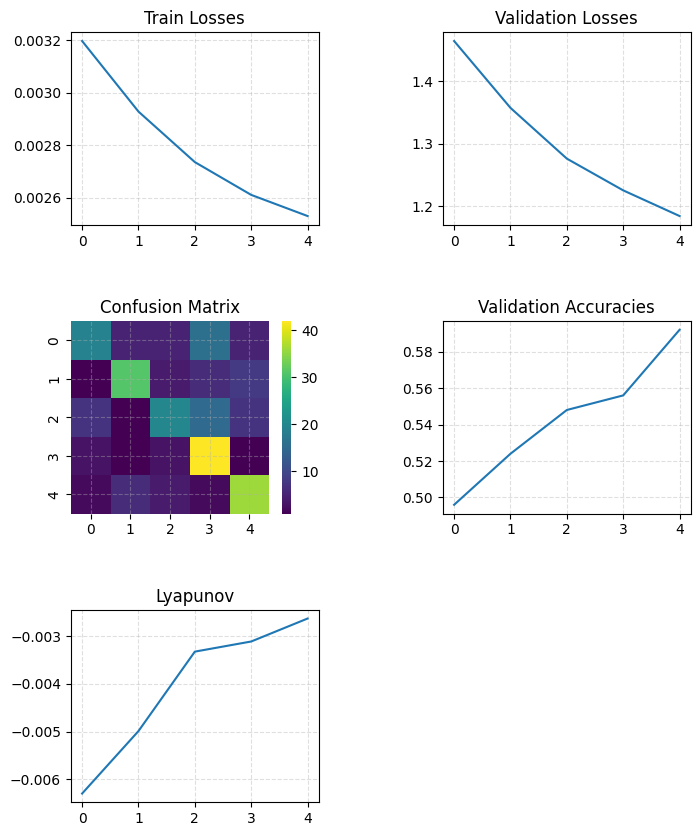

In [32]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("c5_CL_5.png", dpi=300)

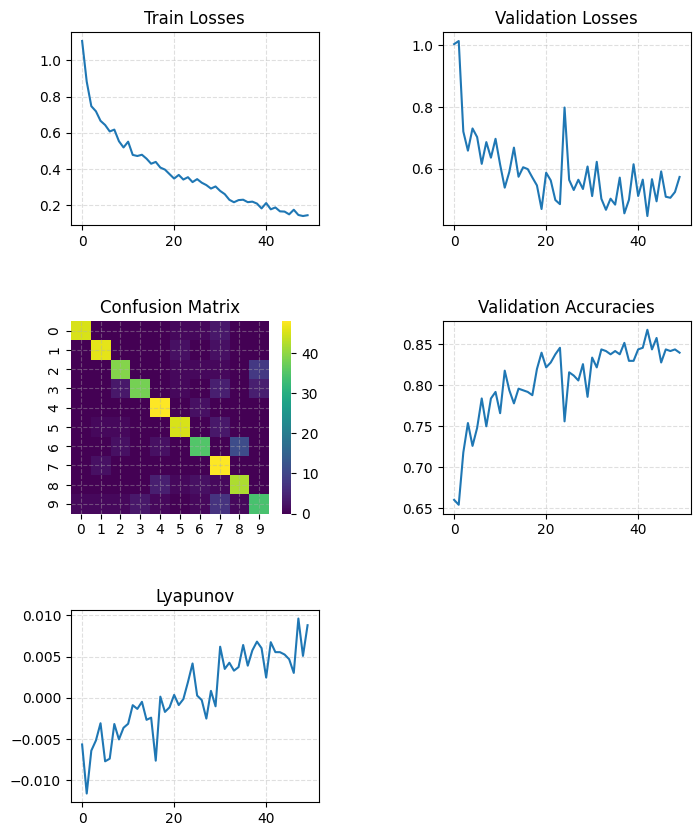

In [33]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("c5_CL_5.png", dpi=300)

In [43]:
train_losses_kd, val_losses_kd, confusion_matrices_kd, val_accuracies_kd, lyas_kd, time_kd = [dict_all_kd[k] for k in dict_all]

In [47]:
train_losses_c_slr, val_losses_c_slr, confusion_matrices_c_slr, val_accuracies_c_slr, lyas_c_slr, time_c_slr = [dict_all_c_slr[k] for k in dict_all]

In [50]:
train_losses_c_kd, val_losses_c_kd, confusion_matrices_c_kd, val_accuracies_c_kd, lyas_c_kd, time_c_kd = [dict_all_c_kd[k] for k in dict_all]

In [53]:
train_losses_slr, val_losses_slr, confusion_matrices_slr, val_accuracies_slr, lyas_slr, time_slr = [dict_all_slr[k] for k in dict_all]

In [26]:
len(train_losses)

5

In [11]:
time

6805.836066007614

In [15]:
time

8009.460628271103

<Axes: >

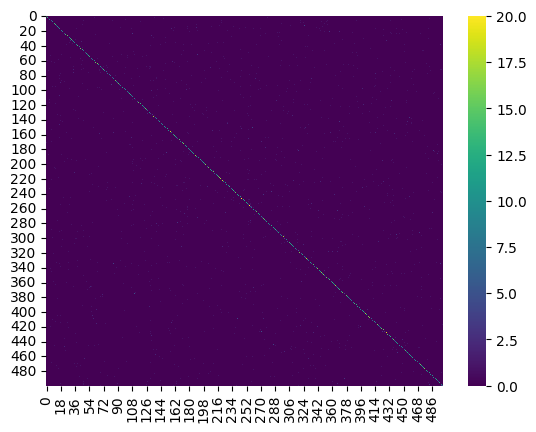

In [45]:
sns.heatmap(confusion_matrices[-1], cmap="viridis")

<Axes: >

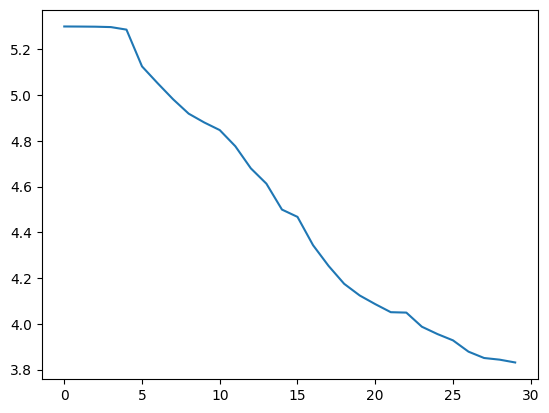

In [6]:
sns.lineplot(val_losses)

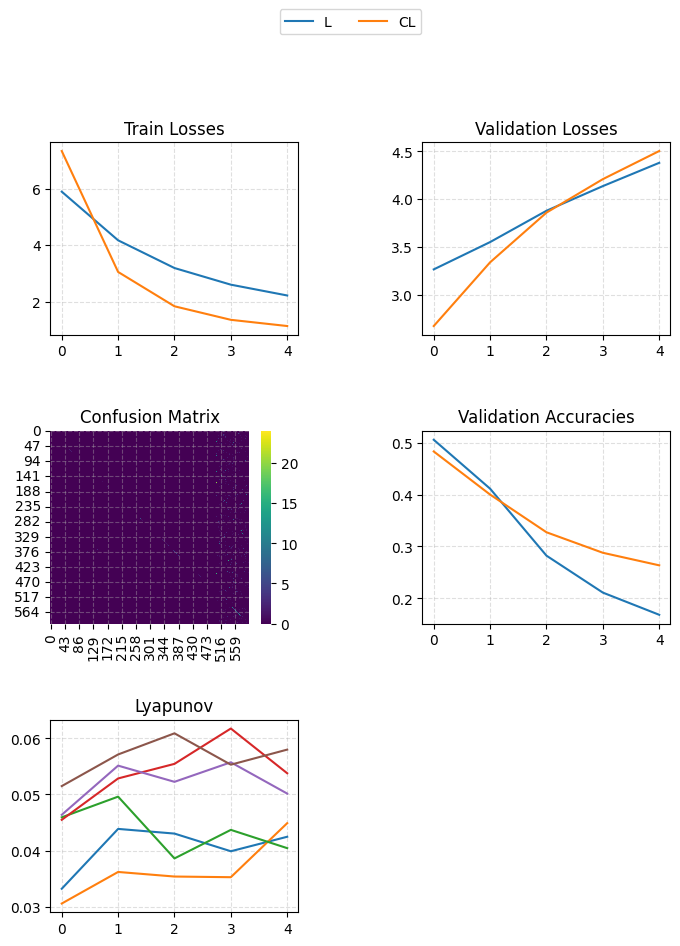

In [56]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses, label="L")
# axes[0,0].plot(train_losses_kd, label="Lkd")
# axes[0,0].plot(train_losses_slr, label="L_slr")
axes[0,0].plot(train_losses_c, label="CL")
# axes[0,0].plot(train_losses_c_slr, label="CL_slr")
# axes[0,0].plot(train_losses_c_kd, label="CL_kd")
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses, label="L")
# axes[0,1].plot(val_losses_kd, label="Lkd")
# axes[0,1].plot(val_losses_slr, label="L_slr")
axes[0,1].plot(val_losses_c, label="CL")
# axes[0,1].plot(val_losses_c_slr, label="CL_slr")
# axes[0,1].plot(val_losses_c_kd, label="CL_kd")
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies, label="L")
# axes[1,1].plot(val_accuracies_kd, label="Lkd")
# axes[1,1].plot(val_accuracies_slr, label="L_slr")
axes[1,1].plot(val_accuracies_c, label="CL")
# axes[1,1].plot(val_accuracies_c_slr, label="CL_slr")
# axes[1,1].plot(val_accuracies_c_kd, label="CL_kd")
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas, label="L")
axes[2,0].plot(lyas_kd, label="Lkd")
axes[2,0].plot(lyas_slr, label="L_slr")
axes[2,0].plot(lyas_c, label="CL")
axes[2,0].plot(lyas_c_slr, label="CL_slr")
axes[2,0].plot(lyas_c_kd, label="CL_kd")
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
# plt.savefig("200c_60e_param1.png", dpi=300)

In [ ]:
lyas[-1]

0.03352885693311691

In [7]:
sorted_CL_keys = sorted(all_CL_data.keys(), key=lambda x: int(x.split('_c')[-1]))

In [49]:
sorted_L_keys = sorted(all_L_data.keys(), key=lambda x: int(x.split('_c')[-1]))

In [50]:
sorted_L_keys

['auto_L_c5',
 'auto_L_c10',
 'auto_L_c15',
 'auto_L_c50',
 'auto_L_c60',
 'auto_L_c70',
 'auto_L_c80',
 'auto_L_c90']

In [17]:
all_L_data["auto_L_c50"].keys()

dict_keys(['train_losses', 'val_losses', 'confusion_matrices', 'val_accuracies', 'lyas', 'time'])

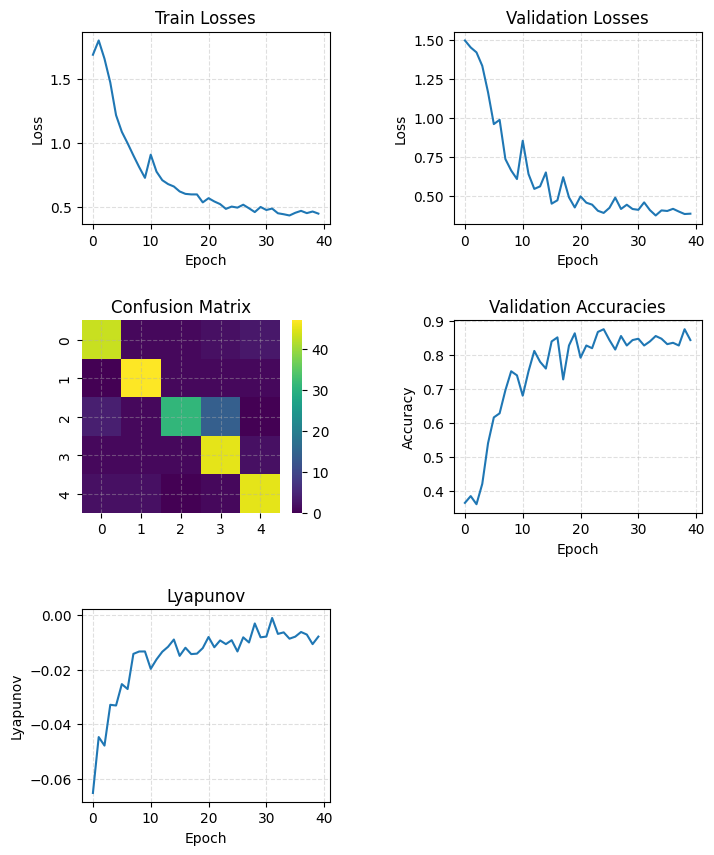

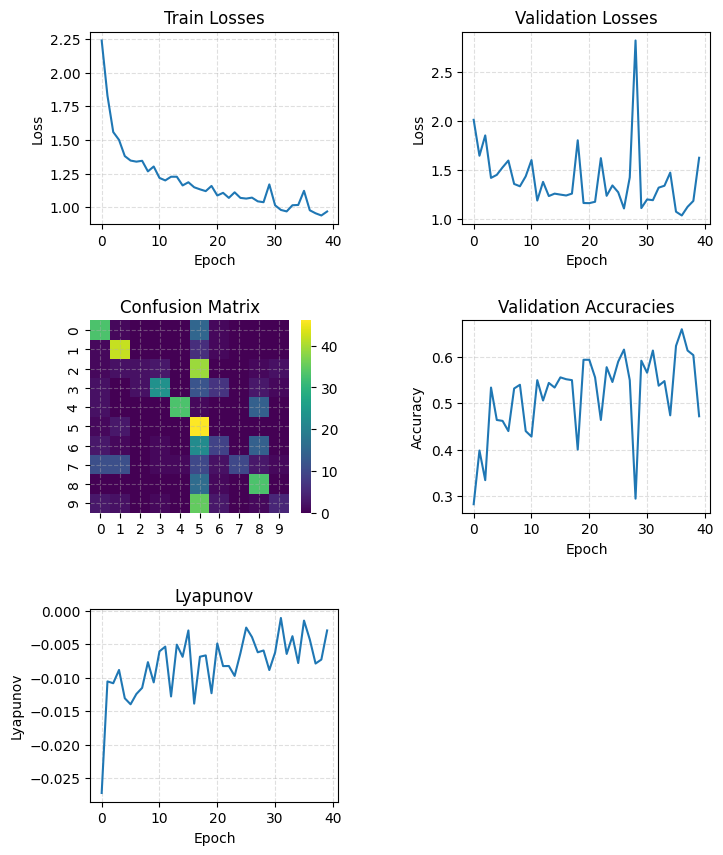

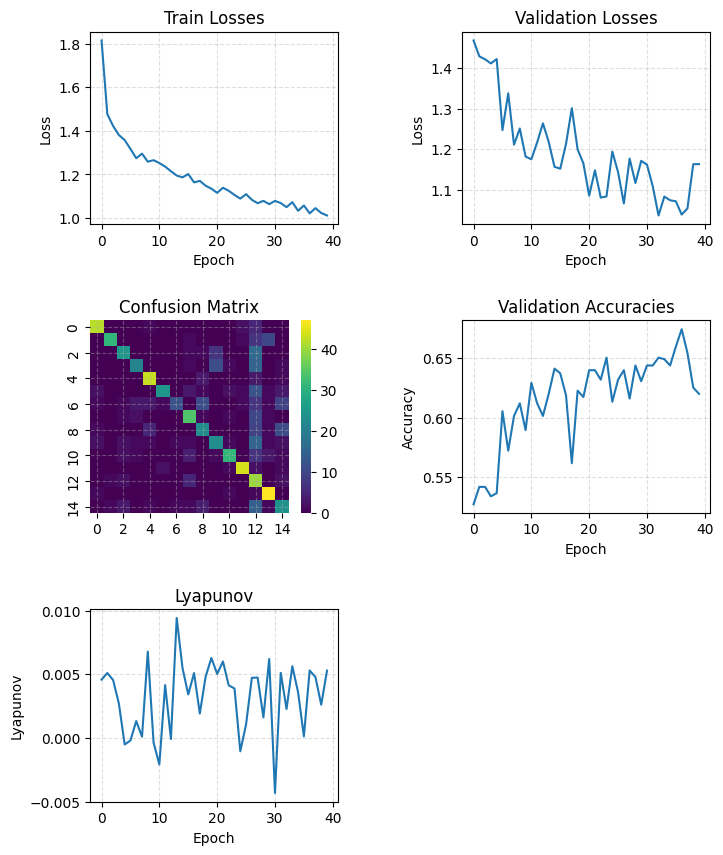

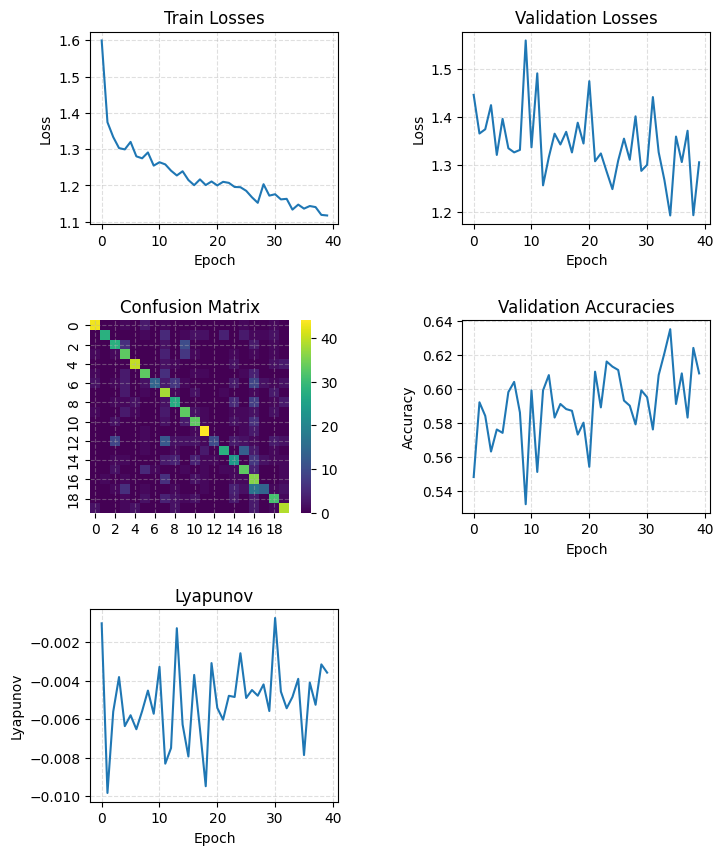

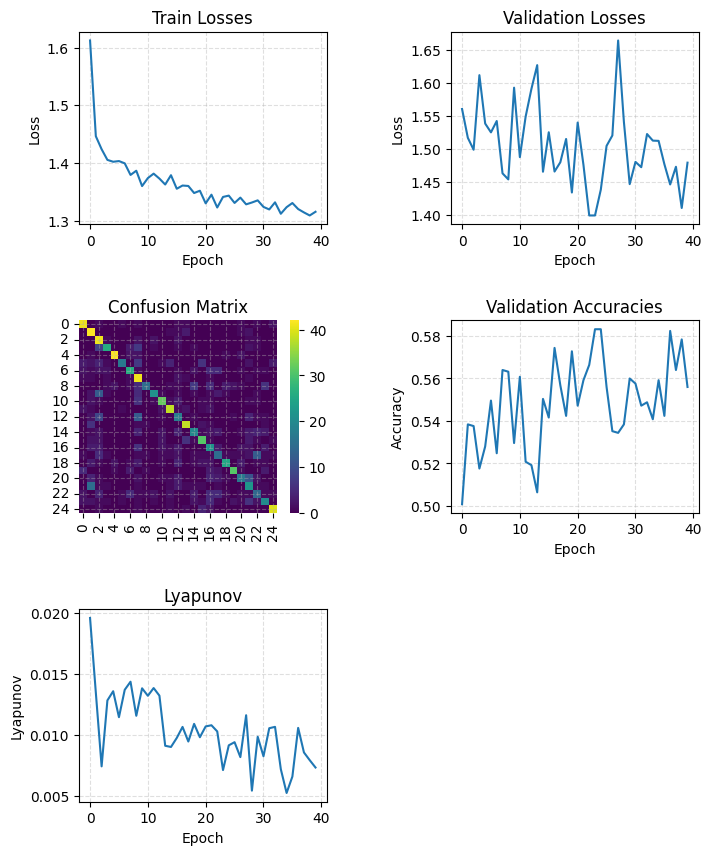

In [9]:
# plot loop
for i in sorted_CL_keys:
    fig, axes = plt.subplots(3,2, figsize=(8,10))

    plt.subplots_adjust(
        wspace=0.5,
        hspace=0.5
    )

    axes[0,0].plot(all_CL_data[i]["train_losses"])
    axes[0,0].set_title("Train Losses")
    axes[0,0].set_xlabel("Epoch")
    axes[0,0].set_ylabel("Loss")

    axes[0,1].plot(all_CL_data[i]["val_losses"])
    axes[0,1].set_title("Validation Losses")
    axes[0,1].set_xlabel("Epoch")
    axes[0,1].set_ylabel("Loss")

    sns.heatmap(all_CL_data[i]["confusion_matrices"][-1], ax=axes[1,0], cmap="viridis")
    axes[1,0].set_title("Confusion Matrix")

    axes[1,1].plot(all_CL_data[i]["val_accuracies"])
    axes[1,1].set_title("Validation Accuracies")
    axes[1,1].set_xlabel("Epoch")
    axes[1,1].set_ylabel("Accuracy")

    axes[2,0].plot(all_CL_data[i]["lyas"])
    axes[2,0].set_title("Lyapunov")
    axes[2,0].set_xlabel("Epoch")
    axes[2,0].set_ylabel("Lyapunov")

    axes[2,1].axis("off")

    for ax in axes.flatten():
        ax.grid(True, linestyle="--", alpha=0.4)

    plt.savefig(f"{i}.png", dpi=300)

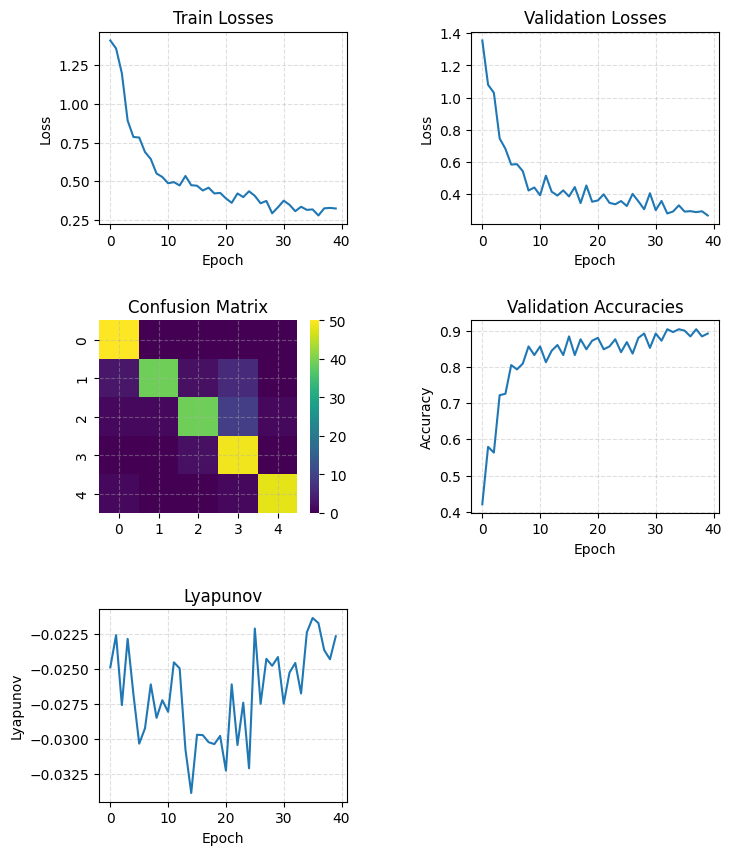

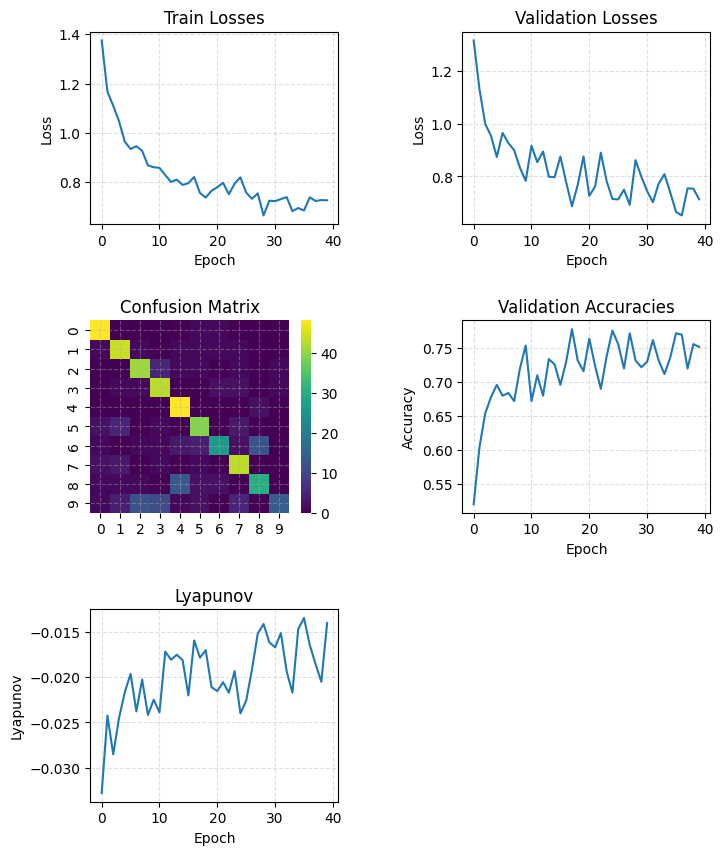

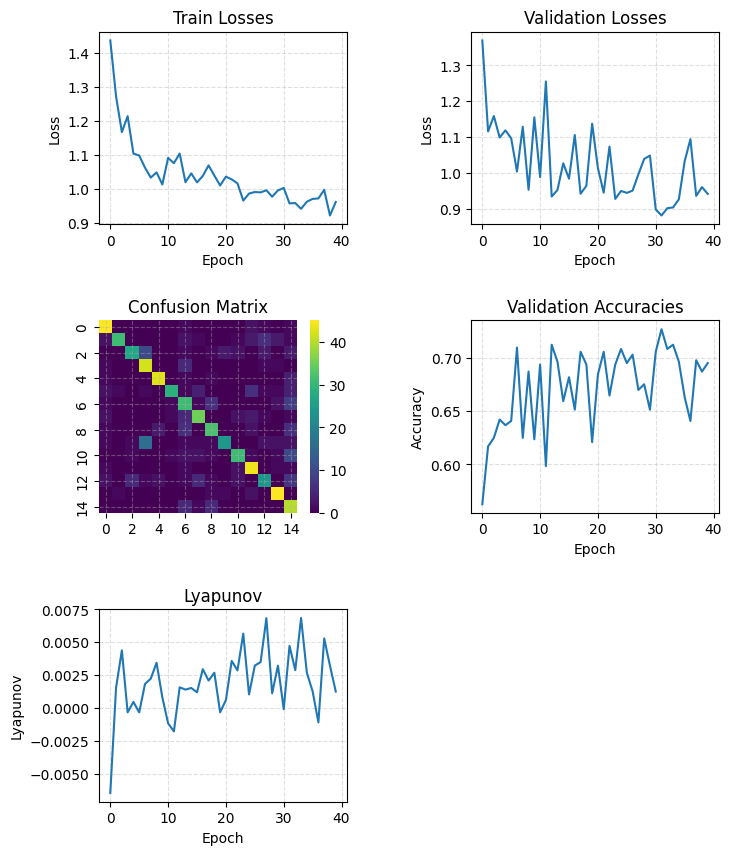

In [19]:
# plot loop
for i in sorted_L_keys[:3]:
    fig, axes = plt.subplots(3,2, figsize=(8,10))

    plt.subplots_adjust(
        wspace=0.5,
        hspace=0.5
    )

    axes[0,0].plot(all_L_data[i]["train_losses"])
    axes[0,0].set_title("Train Losses")
    axes[0,0].set_xlabel("Epoch")
    axes[0,0].set_ylabel("Loss")

    axes[0,1].plot(all_L_data[i]["val_losses"])
    axes[0,1].set_title("Validation Losses")
    axes[0,1].set_xlabel("Epoch")
    axes[0,1].set_ylabel("Loss")

    sns.heatmap(all_L_data[i]["confusion_matrices"][-1], ax=axes[1,0], cmap="viridis")
    axes[1,0].set_title("Confusion Matrix")

    axes[1,1].plot(all_L_data[i]["val_accuracies"])
    axes[1,1].set_title("Validation Accuracies")
    axes[1,1].set_xlabel("Epoch")
    axes[1,1].set_ylabel("Accuracy")

    axes[2,0].plot(all_L_data[i]["lyas"])
    axes[2,0].set_title("Lyapunov")
    axes[2,0].set_xlabel("Epoch")
    axes[2,0].set_ylabel("Lyapunov")

    axes[2,1].axis("off")

    for ax in axes.flatten():
        ax.grid(True, linestyle="--", alpha=0.4)

    # plt.savefig(f"{i}.png", dpi=300)

In [29]:
sorted_SL_keys = sorted(all_SL_data.keys(), key=lambda x: int(x.split('_c')[-1]))

In [30]:
sorted_SL_keys

['auto_SL_c50', 'auto_SL_c60', 'auto_SL_c70', 'auto_SL_c80']

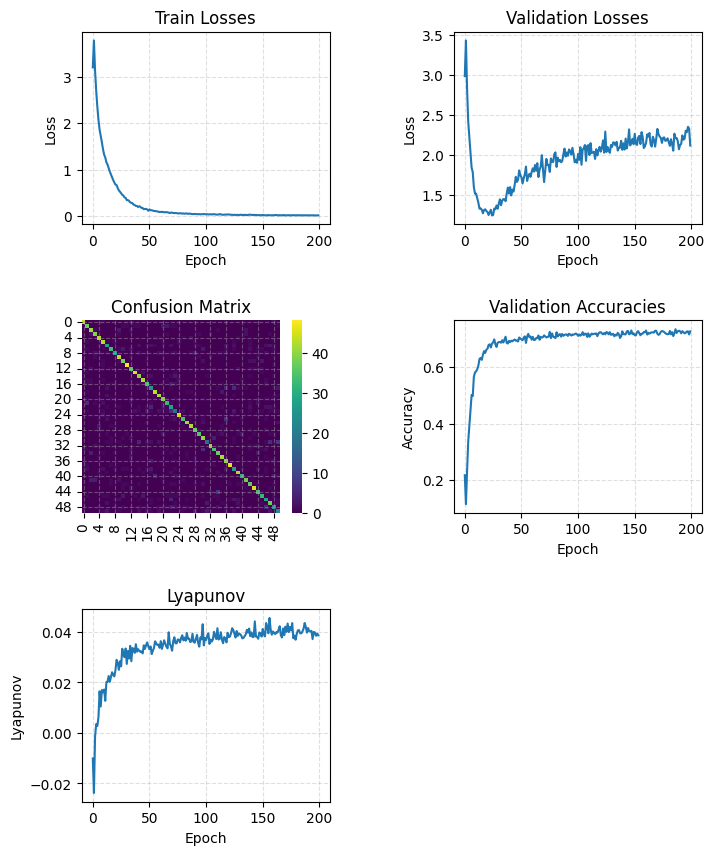

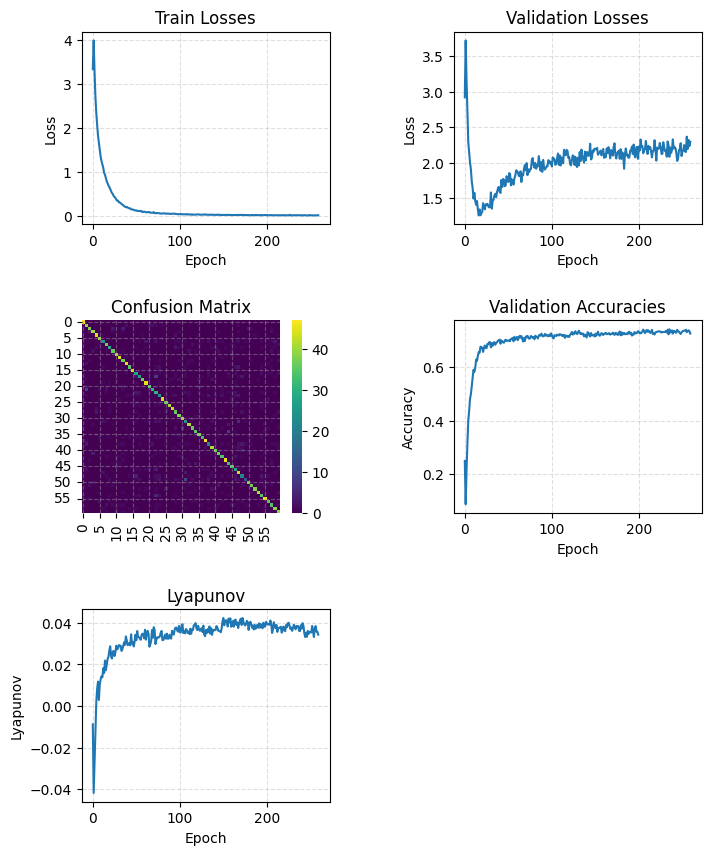

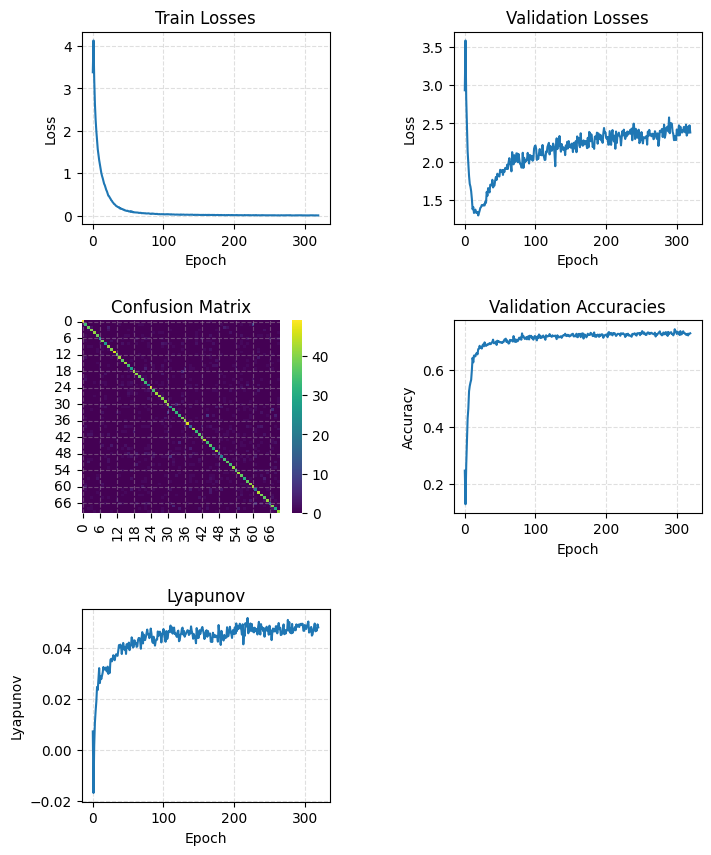

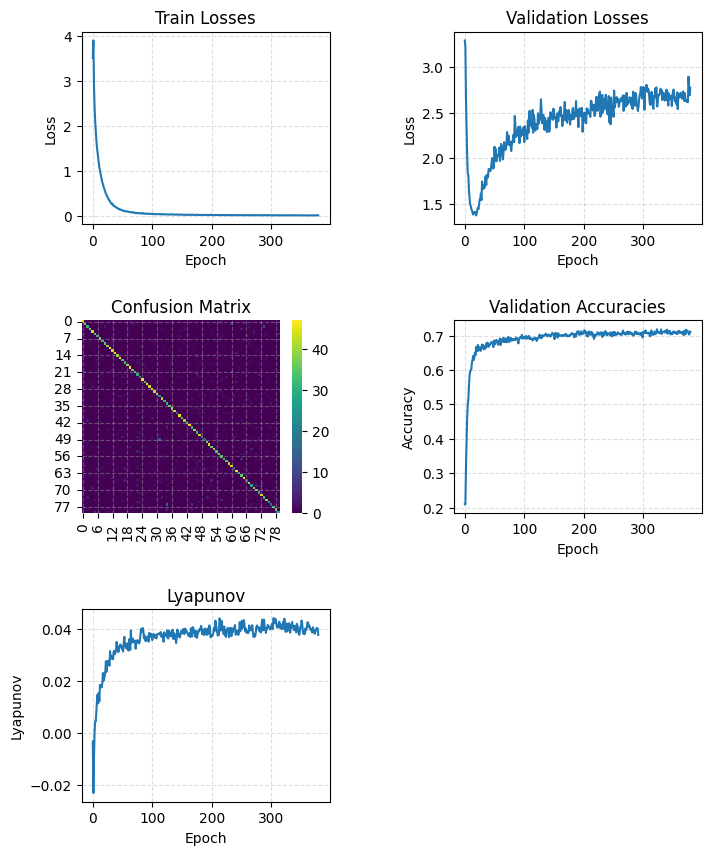

In [29]:
# plot loop
for i in sorted_SL_keys:
    fig, axes = plt.subplots(3,2, figsize=(8,10))

    plt.subplots_adjust(
        wspace=0.5,
        hspace=0.5
    )

    axes[0,0].plot(all_SL_data[i]["train_losses"])
    axes[0,0].set_title("Train Losses")
    axes[0,0].set_xlabel("Epoch")
    axes[0,0].set_ylabel("Loss")

    axes[0,1].plot(all_SL_data[i]["val_losses"])
    axes[0,1].set_title("Validation Losses")
    axes[0,1].set_xlabel("Epoch")
    axes[0,1].set_ylabel("Loss")

    sns.heatmap(all_SL_data[i]["confusion_matrices"][-1], ax=axes[1,0], cmap="viridis")
    axes[1,0].set_title("Confusion Matrix")

    axes[1,1].plot(all_SL_data[i]["val_accuracies"])
    axes[1,1].set_title("Validation Accuracies")
    axes[1,1].set_xlabel("Epoch")
    axes[1,1].set_ylabel("Accuracy")

    axes[2,0].plot(all_SL_data[i]["lyas"])
    axes[2,0].set_title("Lyapunov")
    axes[2,0].set_xlabel("Epoch")
    axes[2,0].set_ylabel("Lyapunov")

    axes[2,1].axis("off")

    for ax in axes.flatten():
        ax.grid(True, linestyle="--", alpha=0.4)

    plt.savefig(f"{i}.png", dpi=300)

In [33]:
SL_val_accuracies = []
for i in sorted_SL_keys:
    SL_val_accuracies.append(all_SL_data[i]["val_accuracies"][-1])

In [51]:
sorted_L_keys

['auto_L_c5',
 'auto_L_c10',
 'auto_L_c15',
 'auto_L_c50',
 'auto_L_c60',
 'auto_L_c70',
 'auto_L_c80',
 'auto_L_c90']

In [52]:
L_val_accuracies = []
for i in sorted_L_keys[:3]:
    L_val_accuracies.append(all_L_data[i]["val_accuracies"][-1])

In [10]:
CL_val_accuracies = []
for i in sorted_CL_keys:
    CL_val_accuracies.append(all_CL_data[i]["val_accuracies"][-1])

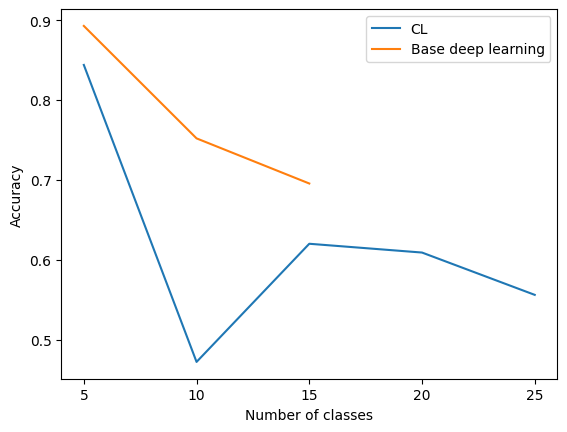

In [53]:
x1= [5,10,15,20,25]
x2= [5,10,15]
plt.plot(x1, CL_val_accuracies, label="CL")
plt.plot(x2, L_val_accuracies, label="Base deep learning")
plt.xlabel("Number of classes")
plt.ylabel("Accuracy")
plt.xticks([5,10,15,20,25])
plt.legend()
plt.savefig("CL_L_compare.png", dpi=300)

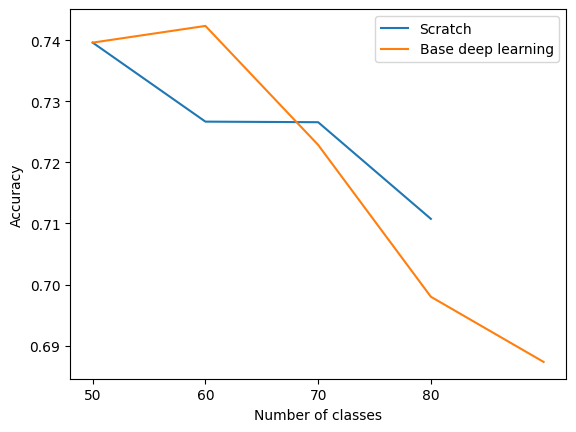

In [43]:
x1= [50,60,70,80]
x2= [50,60,70,80,90]
plt.plot(x1, SL_val_accuracies, label="Scratch")
plt.plot(x2, L_val_accuracies, label="Base deep learning")
plt.xlabel("Number of classes")
plt.ylabel("Accuracy")
plt.xticks([50,60,70,80])
plt.legend()
plt.savefig("compare_val_acc.png", dpi=300)

In [39]:
import numpy as np

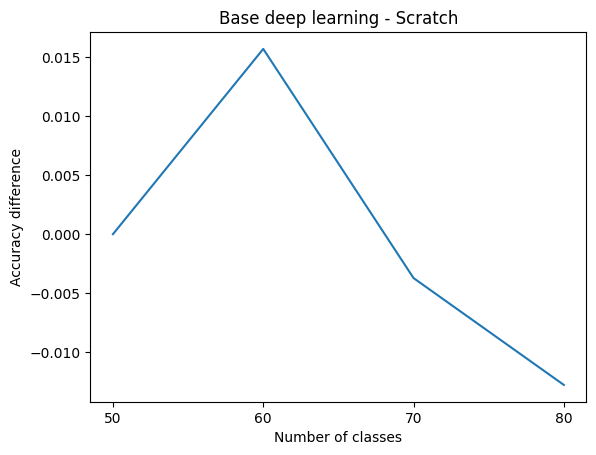

In [42]:
plt.plot([50,60,70,80], np.array(L_val_accuracies[:-1])-np.array(SL_val_accuracies))
plt.title("Base deep learning - Scratch")
plt.xlabel("Number of classes")
plt.ylabel("Accuracy difference")
plt.xticks([50,60,70,80])
plt.savefig("val_acc_difference.png", dpi=300)

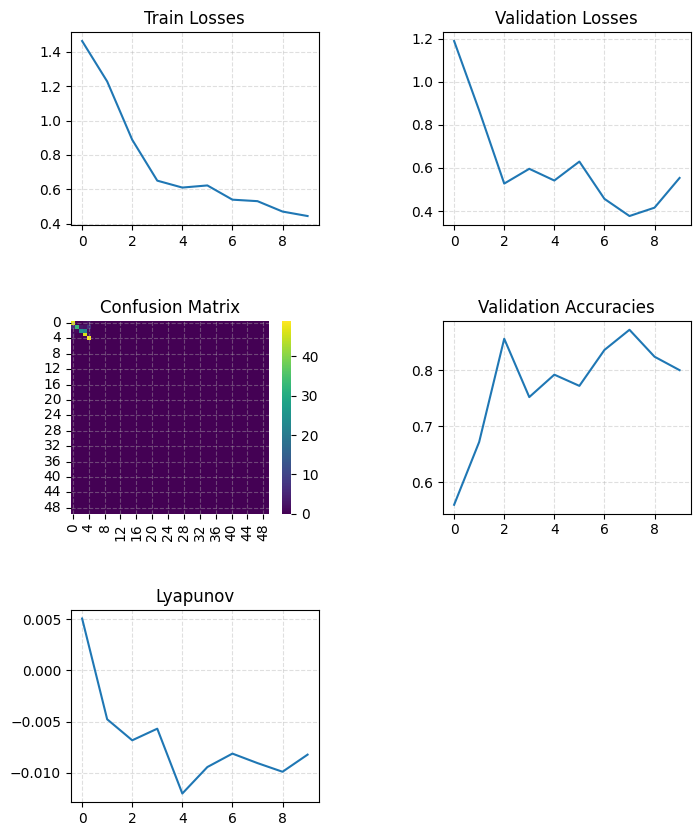

In [61]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("c5_CL_5.png", dpi=300)

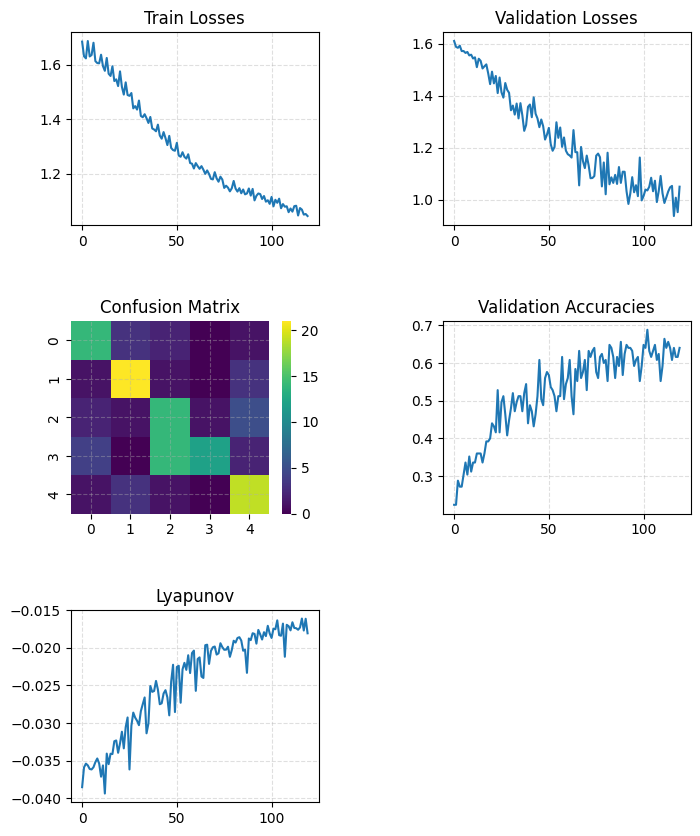

In [19]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

In [10]:
val_accuracies[-1]

0.3815999925136566

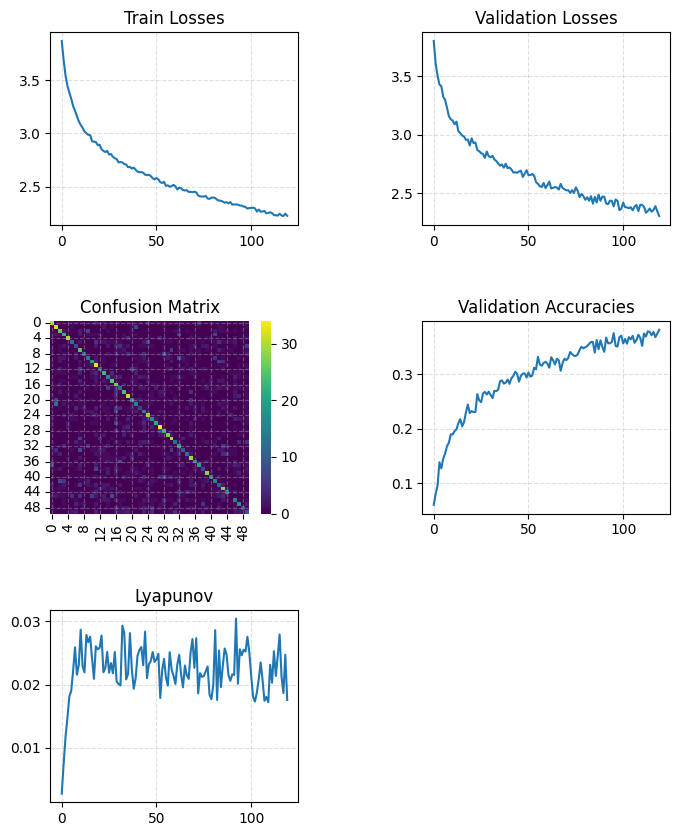

In [9]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

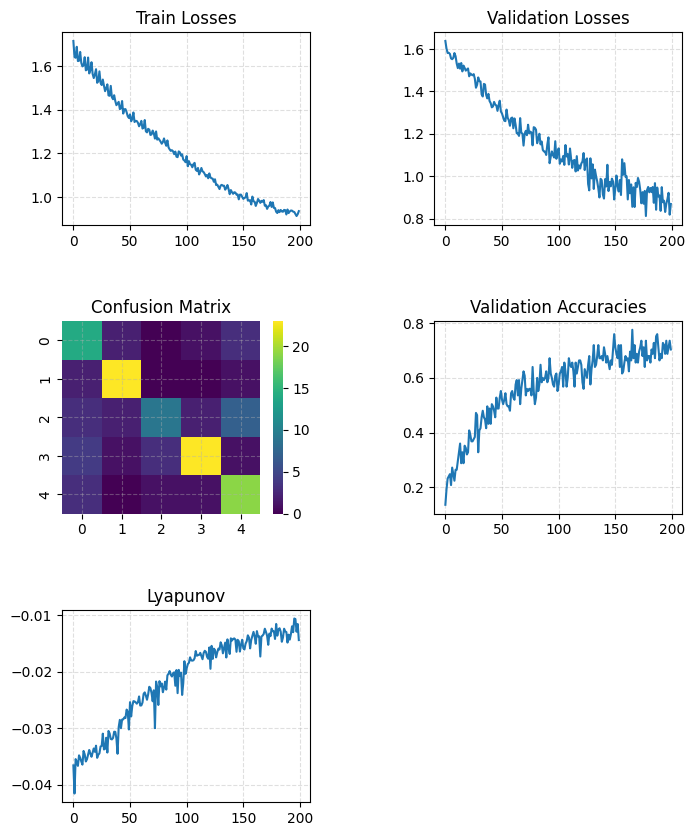

In [5]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

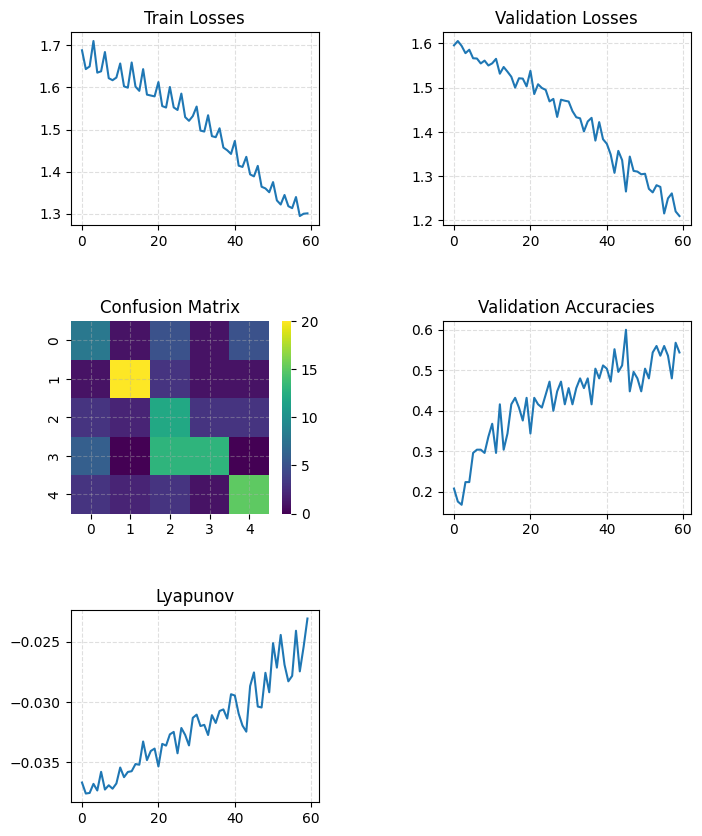

In [16]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

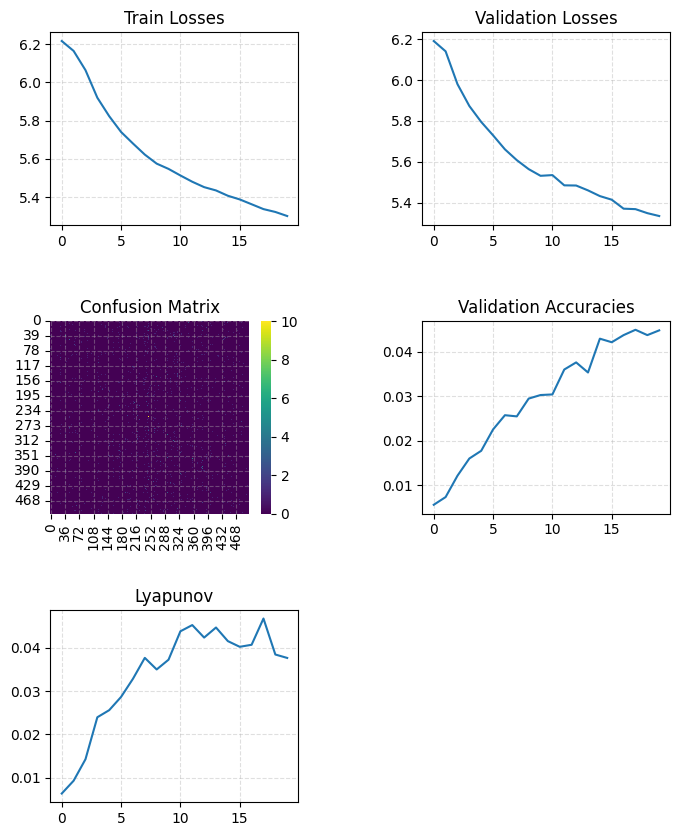

In [23]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

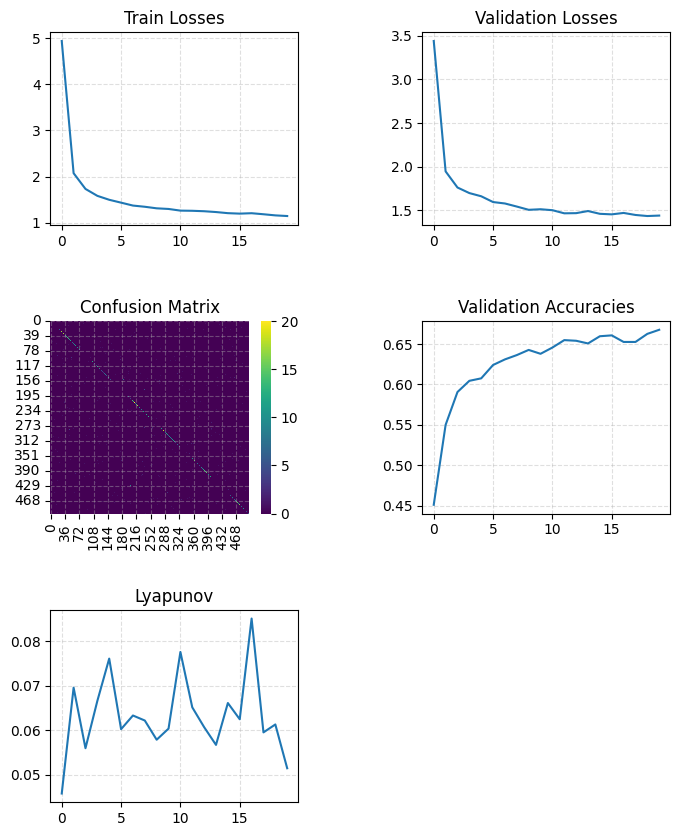

In [14]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

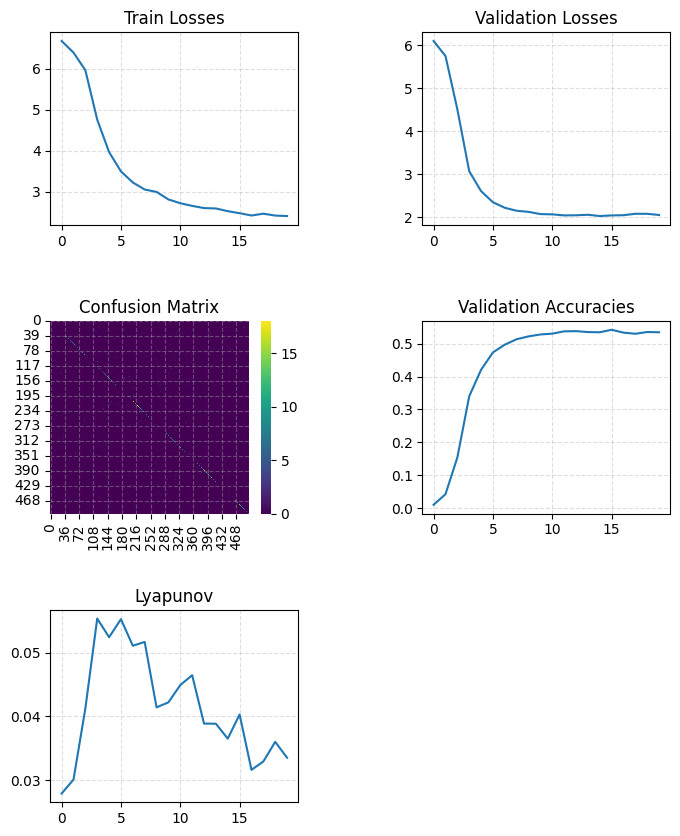

In [10]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("learn_base_cl.png", dpi=300)

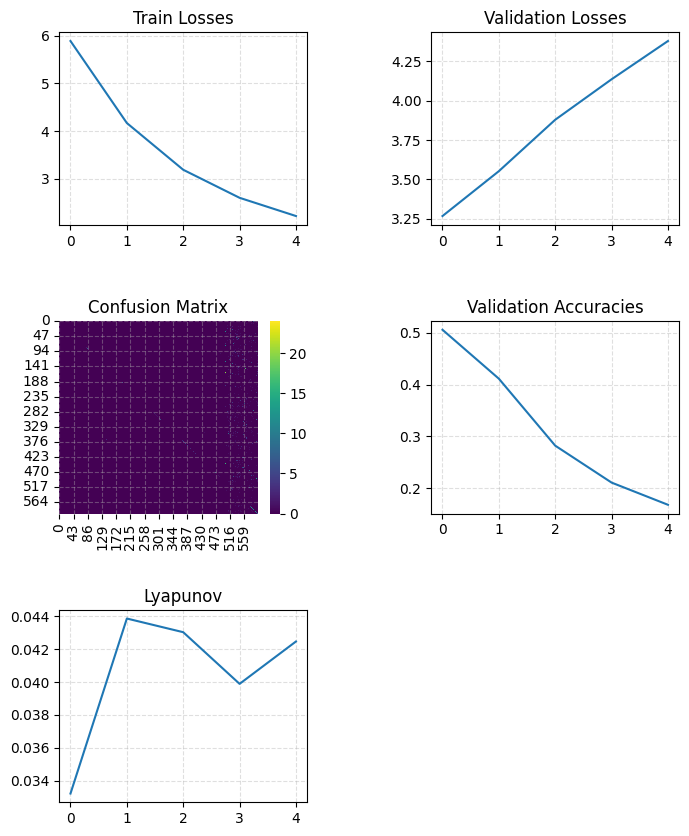

In [27]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("200c_60e_param1.png", dpi=300)

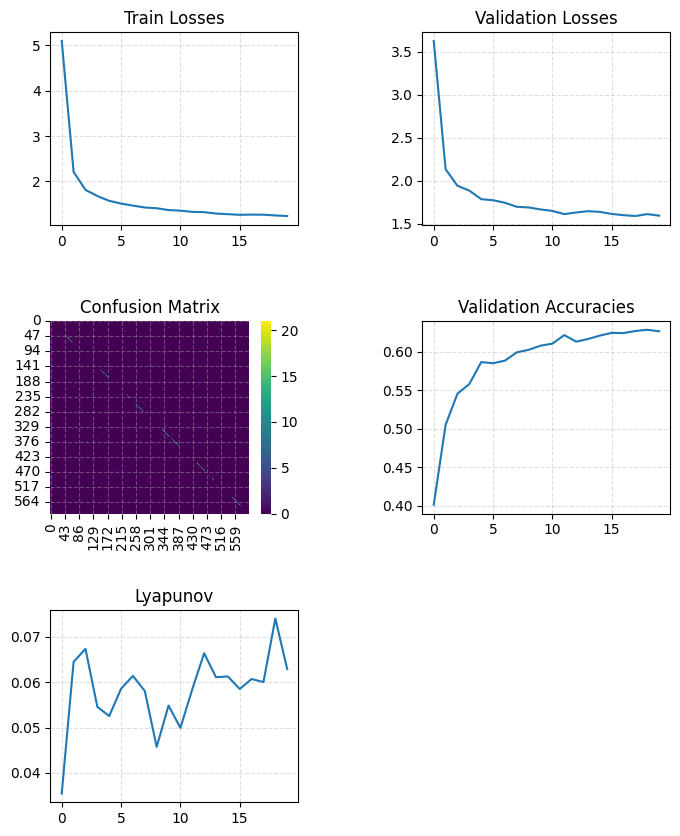

In [12]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("200c_60e_param1.png", dpi=300)

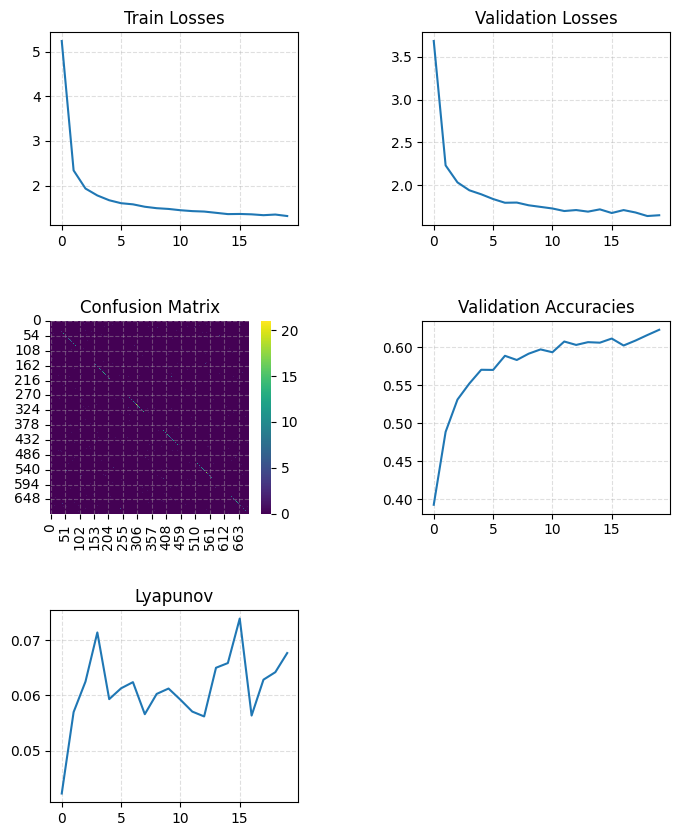

In [16]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("200c_60e_param1.png", dpi=300)

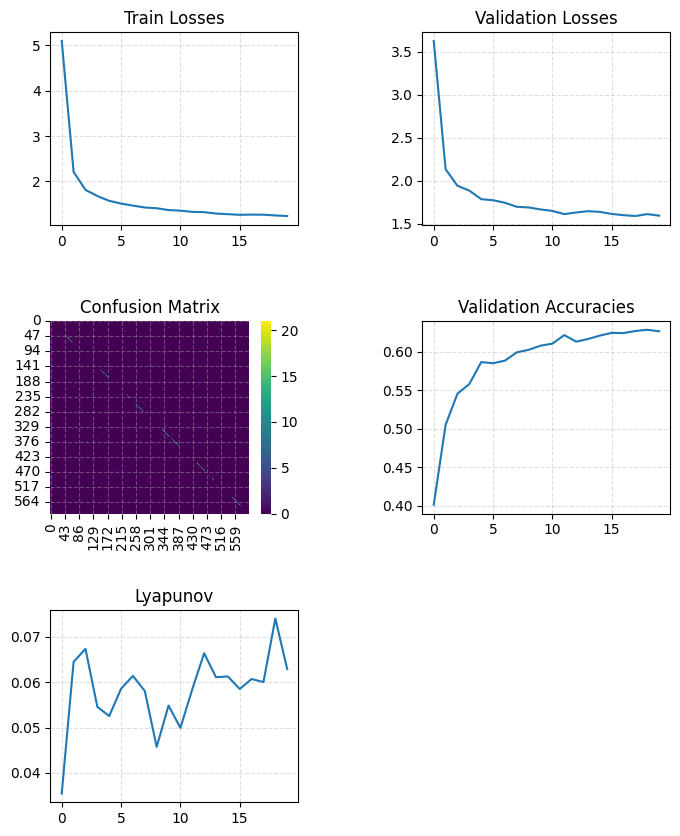

In [54]:
fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(train_losses)
axes[0,0].set_title("Train Losses")

axes[0,1].plot(val_losses)
axes[0,1].set_title("Validation Losses")

sns.heatmap(confusion_matrices[-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(val_accuracies)
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(lyas)
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("200c_60e_param1.png", dpi=300)

In [12]:
val_accuracies

[]

In [6]:
val_accuracies

[tensor(0.2743)]